In [60]:
from google.colab import drive
drive.mount('/content/drive', force_remount = True)

Mounted at /content/drive


In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
path = "/content/drive/MyDrive/Data Machine Learning/Ex2/Bengaluru_House_Data.csv"
df_raw = pd.read_csv(path)
df_raw.shape

(13320, 9)

PHẦN THỰC HÀNH CÓ HƯỚNG DẪN

In [62]:
df_raw.head() # .tail()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [63]:
# Exploratory Data Analysis (EDA)
df = df_raw.copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


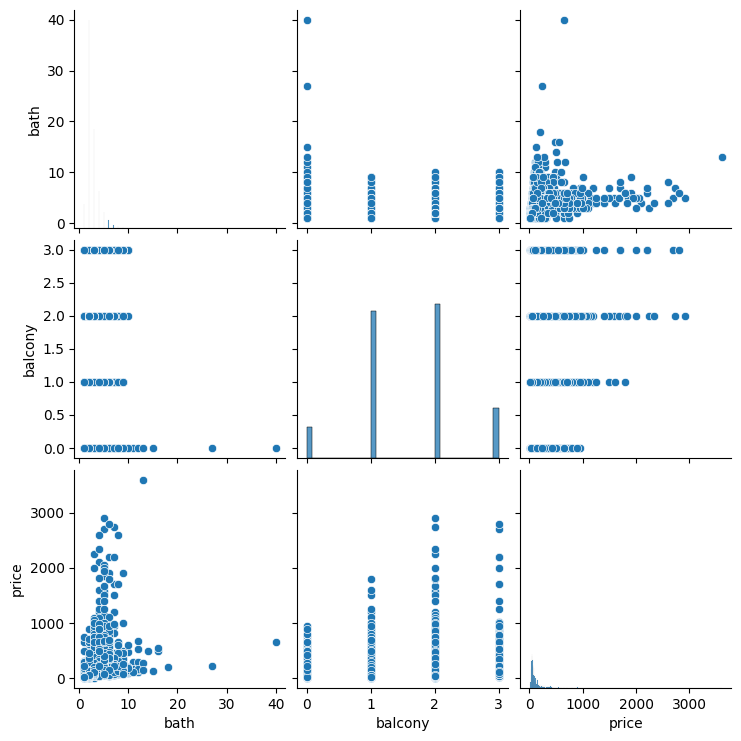

In [64]:
sns.pairplot(df)

<Axes: >

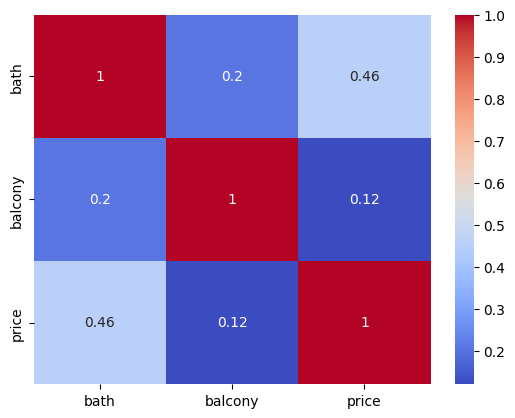

In [65]:
num_vars = ["bath", "balcony", "price"]
sns.heatmap(df[num_vars].corr(),cmap="coolwarm", annot=True)

<Axes: >

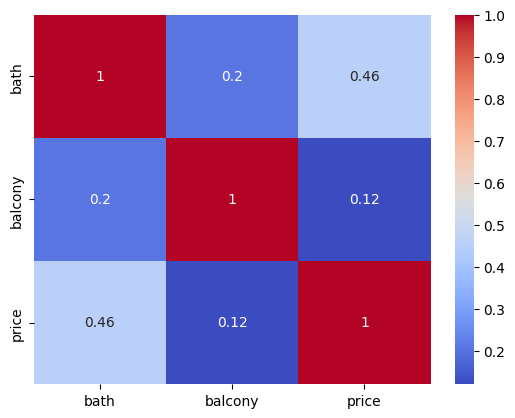

In [66]:
# num_vars = ["bath", "balcony", "price"]
# Add numeric_only=True to only refer to numeric columns, not the "Super-build" one
sns.heatmap(df.corr(numeric_only=True),cmap="coolwarm", annot=True)

In [67]:
df.isnull().sum()
df.isnull().mean()*100

,0
area_type,0.000000
availability,0.000000
location,0.007508
size,0.120120
society,41.306306
total_sqft,0.000000
bath,0.548048
balcony,4.572072
price,0.000000


In [68]:
# thieu nhieu qua nen drop luon cho xong
df2 = df.drop('society', axis='columns')
df2.shape

(13320, 8)

In [69]:
# thieu khong qua nhieu, nen thay vi bo di, thi dien cac gia tri NaN bang mean cua cot do
df2['balcony'] = df2['balcony'].fillna(df2['balcony'].mean())
#
df2.isnull().sum()

,0
area_type,0
availability,0
location,1
size,16
total_sqft,0
bath,73
balcony,0
price,0


In [70]:
df3 = df2.dropna()
df3.shape

(13246, 8)

In [71]:
df3.isnull().sum()

,0
area_type,0
availability,0
location,0
size,0
total_sqft,0
bath,0
balcony,0
price,0


In [72]:
total_sqft_float = []
for str_val in df3['total_sqft']:
  try:
    total_sqft_float.append(float(str_val))
  except:
    try:
      temp = []
      temp = str_val.split('-')
      total_sqft_float.append((float(temp[0])+float(temp[-1]))/2)
    except:
      total_sqft_float.append(np.nan)

In [73]:
 df4 = df3.reset_index(drop=True)

In [74]:
df5 = df4.join(pd.DataFrame({'total_sqft_float':total_sqft_float}))
df5.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price,total_sqft_float
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07,1056.0
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00,2600.0
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440,2.0,3.0,62.00,1440.0
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00,1521.0
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200,2.0,1.0,51.00,1200.0


In [75]:
df5.isnull().sum()

,0
area_type,0
availability,0
location,0
size,0
total_sqft,0
bath,0
balcony,0
price,0
total_sqft_float,46


In [76]:
df6 = df5.dropna()
df6.shape

(13200, 9)

In [77]:
df6.info()

<class 'pandas.core.frame.DataFrame'>
Index: 13200 entries, 0 to 13245
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   area_type         13200 non-null  object 
 1   availability      13200 non-null  object 
 2   location          13200 non-null  object 
 3   size              13200 non-null  object 
 4   total_sqft        13200 non-null  object 
 5   bath              13200 non-null  float64
 6   balcony           13200 non-null  float64
 7   price             13200 non-null  float64
 8   total_sqft_float  13200 non-null  float64
dtypes: float64(4), object(5)
memory usage: 1.0+ MB


In [78]:
df6['size'].value_counts()

,count
size,
2 BHK,5192
3 BHK,4277
4 Bedroom,816
4 BHK,574
3 Bedroom,541
1 BHK,527
2 Bedroom,325
5 Bedroom,293
6 Bedroom,190


In [79]:
size_int = []
for str_val in df6['size']:
  temp=[]
  temp = str_val.split(" ")
  try:
    size_int.append(int(temp[0]))
  except:
    size_int.append(np.nan)
    print("Noice = ",str_val)

In [80]:
df6 = df6.reset_index(drop=True)

In [81]:
df7 = df6.join(pd.DataFrame({'bhk':size_int}))
df7.shape

(13200, 10)

In [82]:
df7.tail()

,area_type,availability,location,size,total_sqft,bath,balcony,price,total_sqft_float,bhk
13195,Built-up Area,Ready To Move,Whitefield,5 Bedroom,3453,4.0,0.000000,231.0,3453.0,5
13196,Super built-up Area,Ready To Move,Richards Town,4 BHK,3600,5.0,1.584376,400.0,3600.0,4
13197,Built-up Area,Ready To Move,Raja Rajeshwari Nagar,2 BHK,1141,2.0,1.000000,60.0,1141.0,2
13198,Super built-up Area,18-Jun,Padmanabhanagar,4 BHK,4689,4.0,1.000000,488.0,4689.0,4
13199,Super built-up Area,Ready To Move,Doddathoguru,1 BHK,550,1.0,1.000000,17.0,550.0,1


<Axes: xlabel='total_sqft_float'>

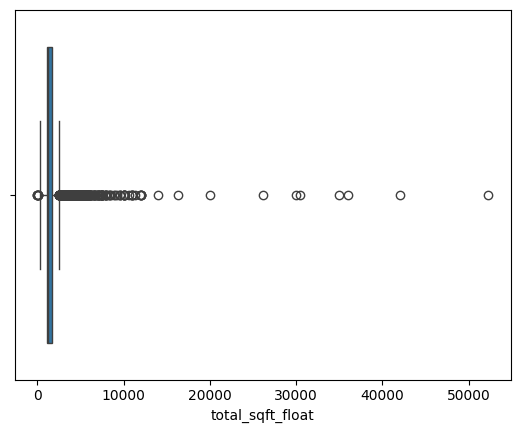

In [83]:
sns.boxplot(x = df7['total_sqft_float'])

In [84]:
df7[df7['total_sqft_float']/df7['bhk'] < 350].head()

,area_type,availability,location,size,total_sqft,bath,balcony,price,total_sqft_float,bhk
9,Plot Area,Ready To Move,Gandhi Bazar,6 Bedroom,1020,6.0,1.584376,370.0,1020.0,6
26,Super built-up Area,Ready To Move,Electronic City,2 BHK,660,1.0,1.000000,23.1,660.0,2
29,Super built-up Area,Ready To Move,Electronic City,3 BHK,1025,2.0,1.000000,47.0,1025.0,3
45,Plot Area,Ready To Move,HSR Layout,8 Bedroom,600,9.0,1.584376,200.0,600.0,8
57,Plot Area,Ready To Move,Murugeshpalya,6 Bedroom,1407,4.0,1.000000,150.0,1407.0,6


In [85]:
df8 = df7[~(df7['total_sqft_float']/df7['bhk'] < 350)]
df8.shape

(12106, 10)

In [86]:
df8['price_per_sqft'] = df8['price']*100000 / df8['total_sqft_float']
df8.head()

/tmp/ipykernel_197/622000310.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df8['price_per_sqft'] = df8['price']*100000 / df8['total_sqft_float']


,area_type,availability,location,size,total_sqft,bath,balcony,price,total_sqft_float,bhk,price_per_sqft
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,1056,2.0,1.0,39.07,1056.0,2,3699.810606
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,2600,5.0,3.0,120.00,2600.0,4,4615.384615
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,1440,2.0,3.0,62.00,1440.0,3,4305.555556
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,1521,3.0,1.0,95.00,1521.0,3,6245.890861
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,1200,2.0,1.0,51.00,1200.0,2,4250.000000


In [87]:
df8.price_per_sqft.describe()

,price_per_sqft
count,12106.000000
mean,6184.466889
std,4019.983503
min,267.829813
25%,4200.030048
50%,5261.108523
75%,6800.000000
max,176470.588235


BẮT ĐẦU PHẦN HOMEWORK

Bài tập 0

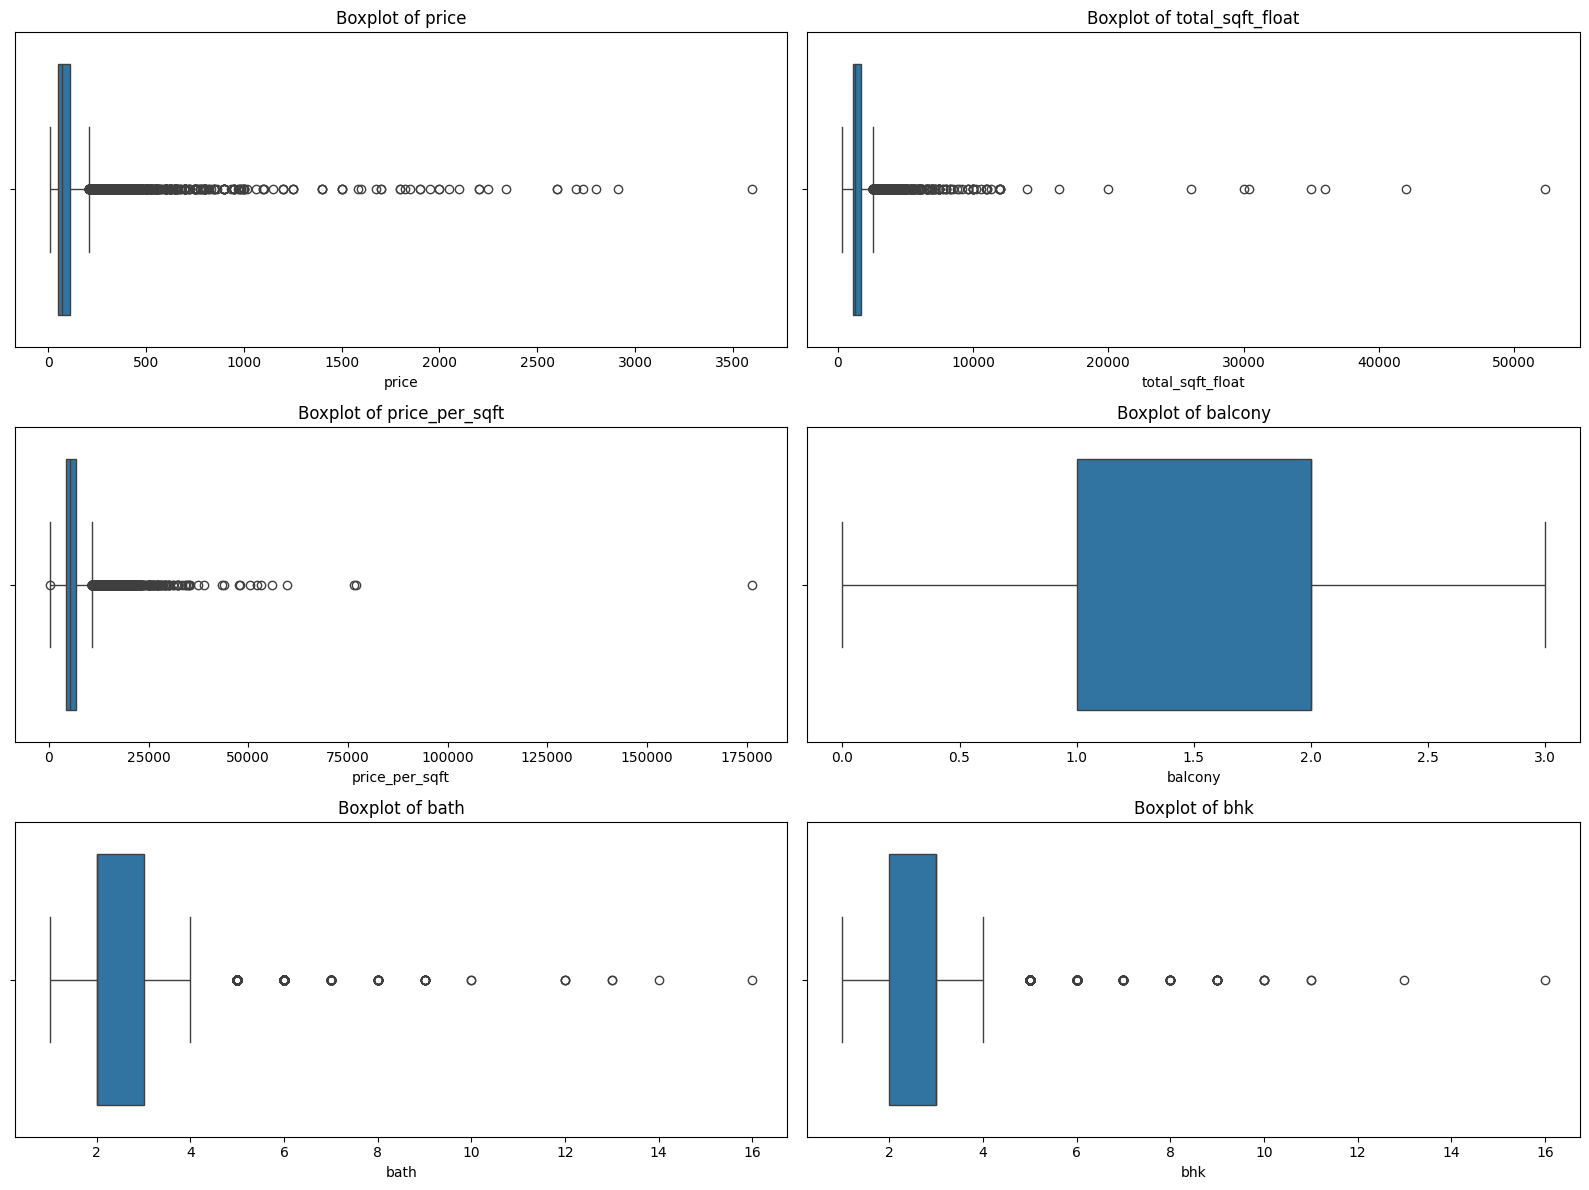

In [88]:
vars = ['price', 'total_sqft_float', 'price_per_sqft', 'balcony', 'bath', 'bhk']
plt.figure(figsize=(16,12))

# 6 o (nhung ma hoi kho nhin)
for i, var in enumerate(vars):
  plt.subplot(3, 2, i+1)
  sns.boxplot(x=df8[var])
  plt.title(f'Boxplot of {var}')

plt.tight_layout()
plt.show()

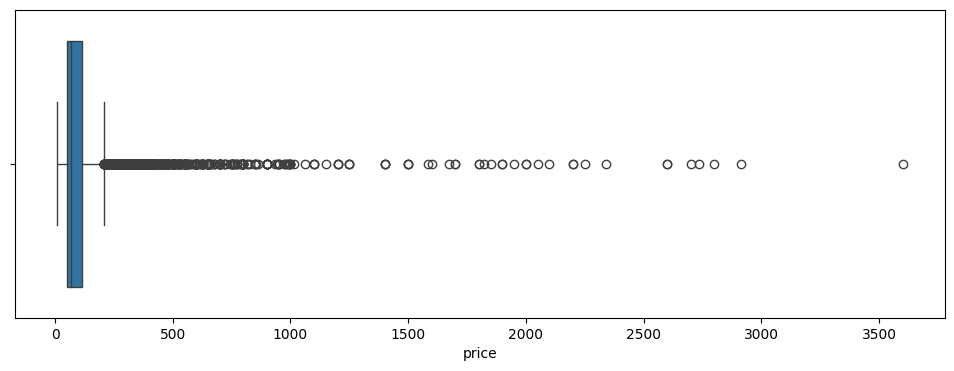

Q1: 49.0
Median:69.14
Q3: 113.0
Lower Whisker: 9.0
Upper Whisker: 208.0
Left Outliers Count: 0
Right Outliers Count: 1231


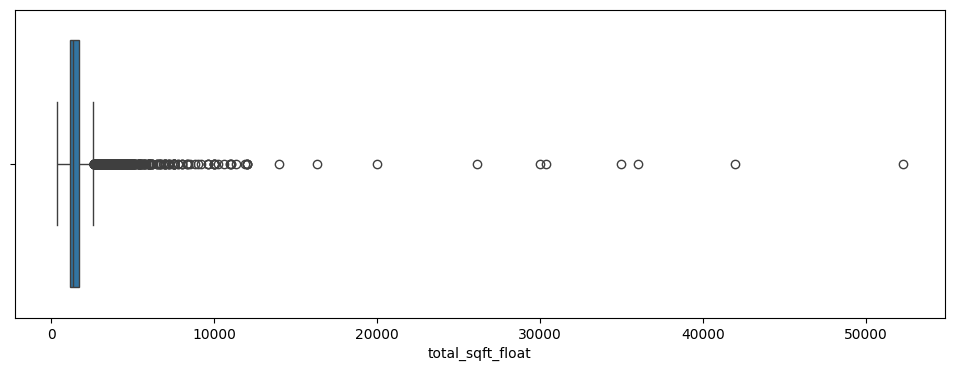

Q1: 1120.0
Median:1305.0
Q3: 1706.0
Lower Whisker: 350.0
Upper Whisker: 2582.0
Left Outliers Count: 0
Right Outliers Count: 1113


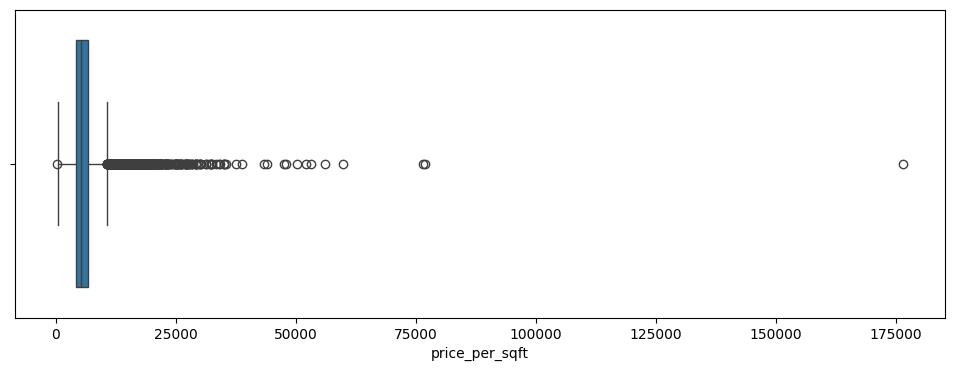

Q1: 4200.030048076923
Median:5261.108522579794
Q3: 6800.0
Lower Whisker: 371.42857142857144
Upper Whisker: 10698.198198198199
Left Outliers Count: 1
Right Outliers Count: 920


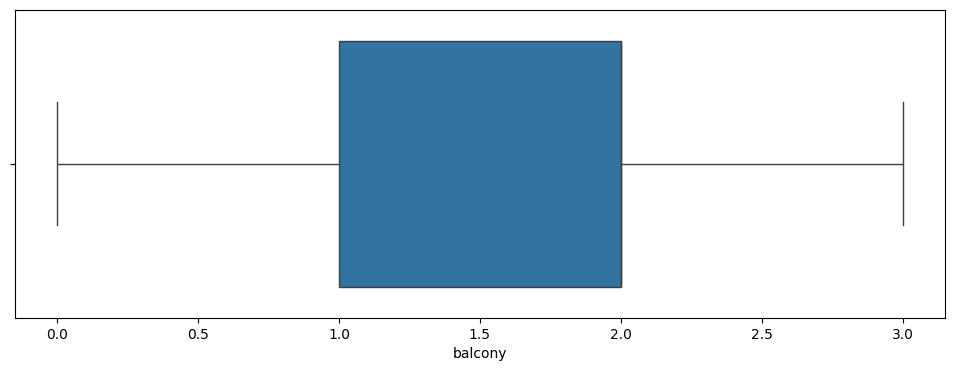

Q1: 1.0
Median:2.0
Q3: 2.0
Lower Whisker: 0.0
Upper Whisker: 3.0
Left Outliers Count: 0
Right Outliers Count: 0


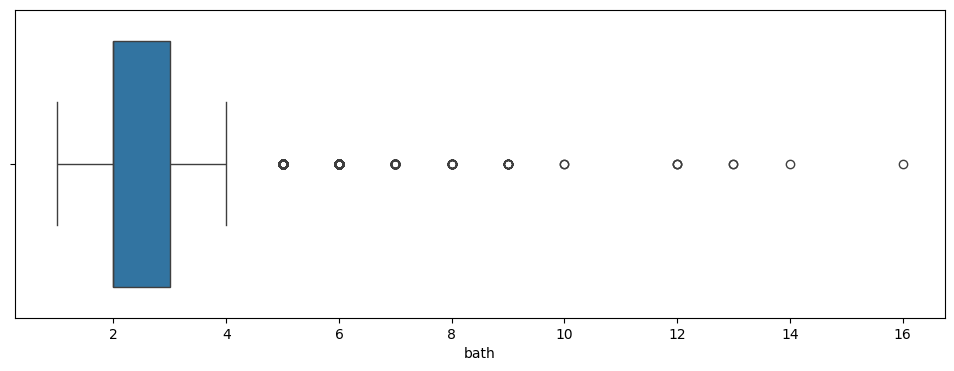

Q1: 2.0
Median:2.0
Q3: 3.0
Lower Whisker: 1.0
Upper Whisker: 4.0
Left Outliers Count: 0
Right Outliers Count: 622


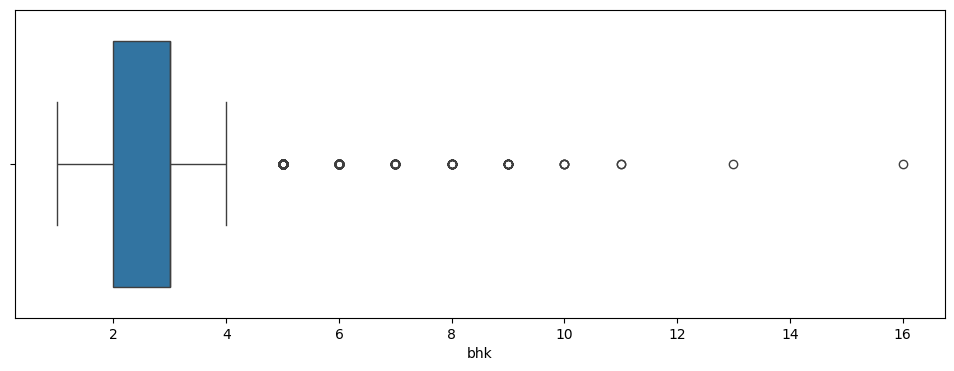

Q1: 2.0
Median:3.0
Q3: 3.0
Lower Whisker: 1
Upper Whisker: 4
Left Outliers Count: 0
Right Outliers Count: 332


In [89]:
# tach ra tung cai to nhin cho de
for var in vars:
  q1 = df8[var].quantile(0.25)
  median = df8[var].median()
  q3 = df8[var].quantile(0.75)

  # theo tinh toan
  iqr = q3 - q1
  lower_fence = q1 - 1.5*iqr
  upper_fence = q3 + 1.5*iqr

  # tim thuc te
  lower_whisker = df8[df8[var] >= lower_fence][var].min()
  upper_whisker = df8[df8[var] <= upper_fence][var].max()

  left_outliers = df8[df8[var] < lower_fence].shape[0]
  right_outliers = df8[df8[var] > upper_fence].shape[0]

  plt.figure(figsize=(12, 4))
  sns.boxplot(x=df8[var])
  plt.show()

  print(f"Q1: {q1}")
  print(f"Median:{median}")
  print(f"Q3: {q3}")
  print(f"Lower Whisker: {lower_whisker}")
  print(f"Upper Whisker: {upper_whisker}")
  print(f"Left Outliers Count: {left_outliers}")
  print(f"Right Outliers Count: {right_outliers}")

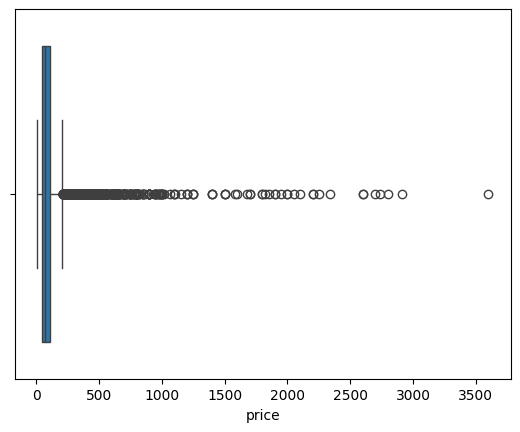

<Figure size 1200x400 with 0 Axes>

Q1: 49.0
Median: 69.14
Q3: 113.0
Lower Whisker: 9.0
Upper Whisker: 208.0


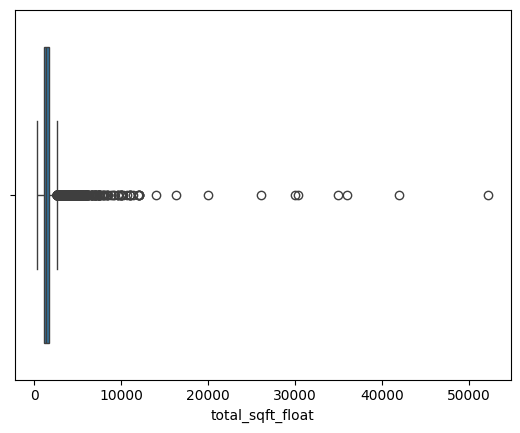

<Figure size 1200x400 with 0 Axes>

Q1: 1120.0
Median: 1305.0
Q3: 1706.0
Lower Whisker: 350.0
Upper Whisker: 2582.0


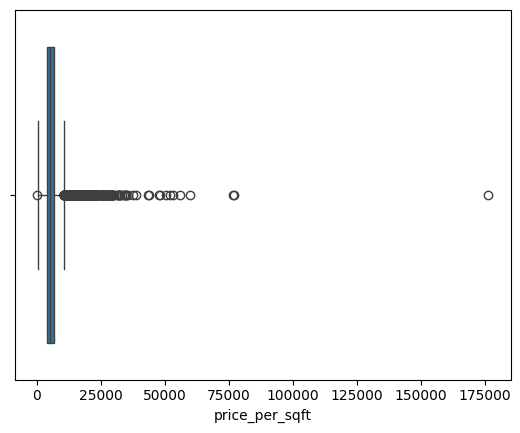

<Figure size 1200x400 with 0 Axes>

Q1: 4200.030048076923
Median: 5261.108522579794
Q3: 6800.0
Lower Whisker: 371.42857142857144
Upper Whisker: 10698.198198198199


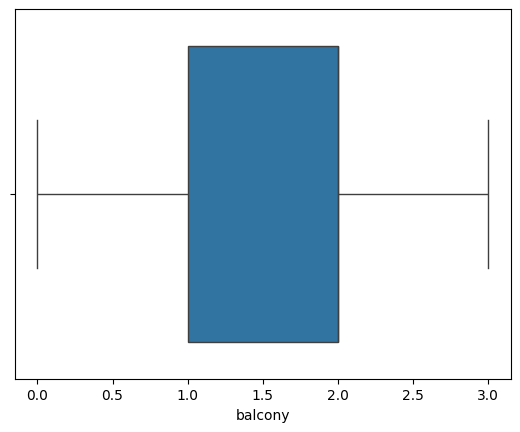

<Figure size 1200x400 with 0 Axes>

Q1: 1.0
Median: 2.0
Q3: 2.0
Lower Whisker: 0.0
Upper Whisker: 3.0


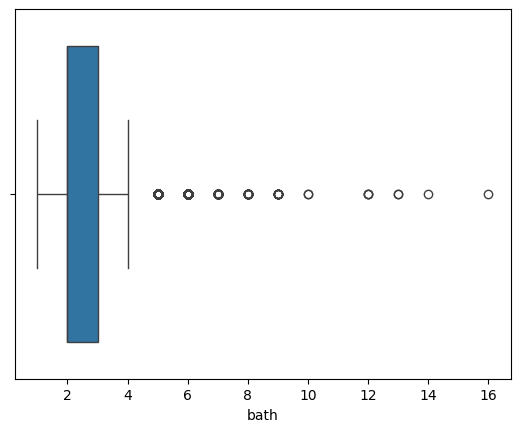

<Figure size 1200x400 with 0 Axes>

Q1: 2.0
Median: 2.0
Q3: 3.0
Lower Whisker: 1.0
Upper Whisker: 4.0


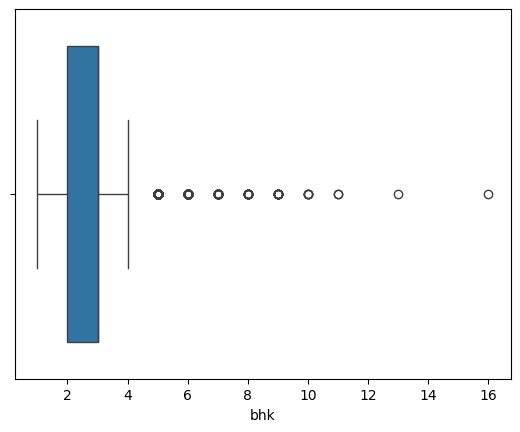

<Figure size 1200x400 with 0 Axes>

Q1: 2.0
Median: 3.0
Q3: 3.0
Lower Whisker: 1.0
Upper Whisker: 4.0


In [90]:
# trich xuat truc tiep tu trong plot
for var in vars:
  ax = sns.boxplot(x=df8[var])
  lines = ax.get_lines()

  median = lines[4].get_xdata()[0]
  lower_whisker = lines[2].get_xdata()[0]
  upper_whisker = lines[3].get_xdata()[0]

  q1 = lines[0].get_xdata()[0]
  q3 = lines[1].get_xdata()[0]

  plt.figure(figsize=(12, 4))
  plt.show()

  print(f"Q1: {q1}")
  print(f"Median: {median}")
  print(f"Q3: {q3}")
  print(f"Lower Whisker: {lower_whisker}")
  print(f"Upper Whisker: {upper_whisker}")

Bài tập 1

In [91]:
def remove_pps_outliers(df):
  # tao dataframe rong
  df_q1 = pd.DataFrame()
  for key, subdf in df.groupby('location'):
    mean = np.mean(subdf.price_per_sqft)
    std = np.std(subdf.price_per_sqft)

    # loc du lieu trong khoang mean - std va mean + std
    filtered_df = subdf[(subdf.price_per_sqft > (mean - std)) & (subdf.price_per_sqft <= (mean + std))]

    # noi bang da loc vao bang tra ve
    df_q1 = pd.concat([df_q1, filtered_df], ignore_index=True)
  return df_q1

df9 = remove_pps_outliers(df8)
df9.shape

(8888, 11)

Bài tập 5

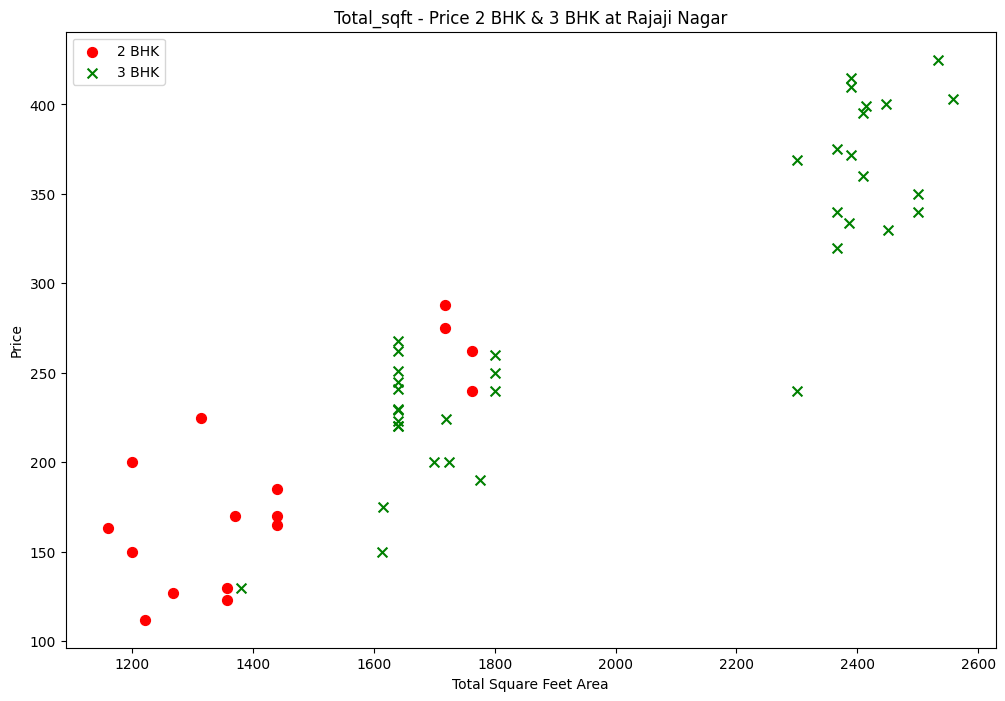

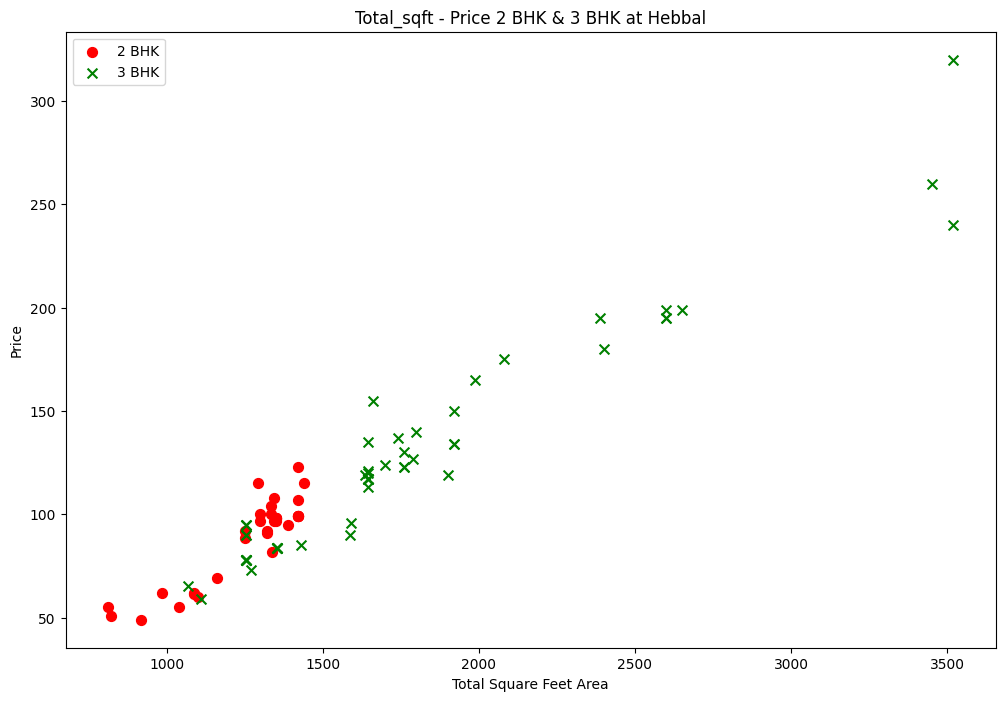

In [92]:
def plot_scatter_chart(df, location):
  bhk2 = df[(df.location == location) & (df.bhk == 2)]
  bhk3 = df[(df.location == location) & (df.bhk == 3)]

  plt.figure(figsize=(12, 8))
  plt.scatter(bhk2.total_sqft_float, bhk2.price, color='red', label='2 BHK', s=50)
  plt.scatter(bhk3.total_sqft_float, bhk3.price, marker='x', color='green', label='3 BHK', s=50)

  plt.xlabel("Total Square Feet Area")
  plt.ylabel("Price")
  plt.title(f"Total_sqft - Price 2 BHK & 3 BHK at {location}")
  plt.legend()
  plt.show()

plot_scatter_chart(df9, "Rajaji Nagar")
plot_scatter_chart(df9, "Hebbal")

Bài tập 6

                      price_per_sqft
area_type                           
Plot  Area               7936.461079
Carpet  Area             5955.799703
Super built-up  Area     5564.771724
Built-up  Area           5533.374127


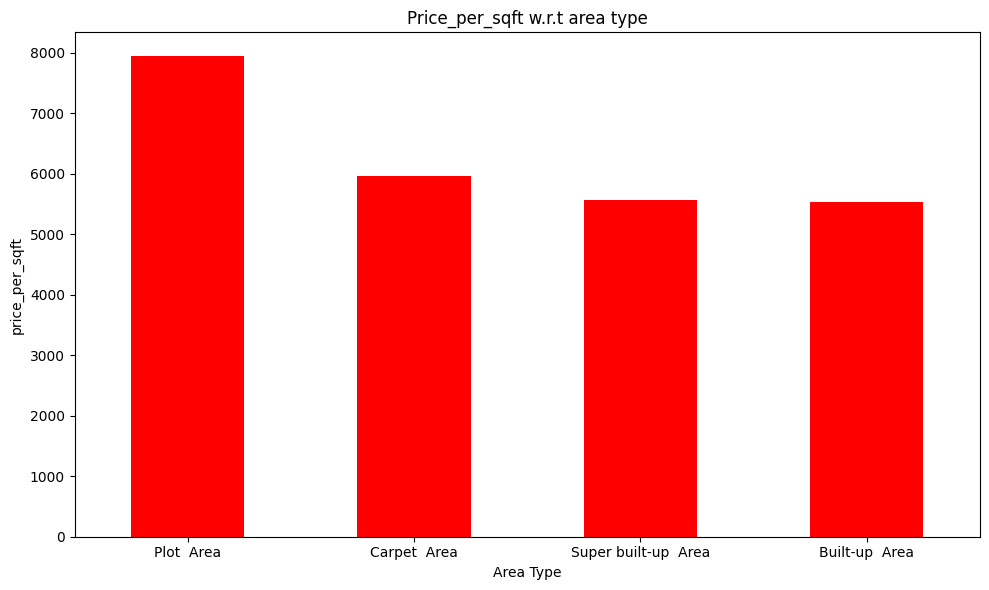

In [114]:
area_stats = df9.groupby('area_type')['price_per_sqft'].mean().sort_values(ascending=False)
print(pd.DataFrame(area_stats))

plt.figure(figsize=(10, 6))
area_stats.plot(kind='bar', color='red')

plt.title("Price_per_sqft w.r.t area type")
plt.xlabel("Area Type")
plt.ylabel("price_per_sqft")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Bài tập 2

XEM BIỂU ĐỒ TRƯỚC

In [95]:
print(df9['location'].value_counts().head(10))

location
Whitefield               476
Sarjapur  Road           292
Electronic City          268
Kanakpura Road           190
Yelahanka                168
Thanisandra              149
Uttarahalli              149
Marathahalli             149
Bannerghatta Road        143
Raja Rajeshwari Nagar    134
Name: count, dtype: int64


In [96]:
comparison_df = df9.groupby(['location', 'bhk'])['price_per_sqft'].mean().unstack()

sample_locations = ["Rajaji Nagar", "Hebbal", "Whitefield"]
comparison_df.loc[sample_locations]

bhk,1,2,3,4,5,6,7,8,9,10
location,,,,,,,,,,
Rajaji Nagar,11363.636364,12995.721715,14106.804545,14010.645195,13757.502633,NaN,NaN,NaN,NaN,NaN
Hebbal,NaN,6966.502770,7011.896703,7863.944040,NaN,NaN,NaN,NaN,NaN,NaN
Whitefield,5827.107688,4996.679556,5556.021537,6783.157705,7836.874287,NaN,NaN,NaN,NaN,NaN


In [97]:
avg_price_table = df9.groupby(['location', 'bhk'])['price'].mean().unstack()
preview_table = avg_price_table.loc[sample_locations]
preview_table.round(2)

bhk,1,2,3,4,5,6,7,8,9,10
location,,,,,,,,,,
Rajaji Nagar,75.00,186.56,289.08,455.32,384.5,NaN,NaN,NaN,NaN,NaN
Hebbal,NaN,88.74,124.43,246.09,NaN,NaN,NaN,NaN,NaN,NaN
Whitefield,43.45,60.34,100.25,238.05,275.5,NaN,NaN,NaN,NaN,NaN


In [98]:
# Loai bo cac data ma co price_per_sqft cua so phong N lai nho hon so phong N-1 (theo tung location)
def remove_bhk_outliers(df):
  exclude_indices = np.array([])

  for location, location_df in df.groupby('location'):
    bhk_stats = {}
    for bhk, bhk_df in location_df.groupby('bhk'):
      bhk_stats[bhk] = {
        'mean': np.mean(bhk_df.price_per_sqft),
        'std': np.std(bhk_df.price_per_sqft),
        'count': bhk_df.shape[0]
      }

    for bhk, bhk_df in location_df.groupby('bhk'):
      stats_prev_bhk = bhk_stats.get(bhk - 1)
      if stats_prev_bhk and stats_prev_bhk['count'] > 5:
        outlier_indices = bhk_df[bhk_df.price_per_sqft < (stats_prev_bhk['mean'])].index.values
        exclude_indices = np.append(exclude_indices, outlier_indices)
    return df.drop(exclude_indices, axis='index')

df10 = remove_bhk_outliers(df9)
print(df10.shape)

(7194, 11)


Bài tập 3

In [100]:
df10.bath.unique()

array([ 3.,  2.,  1.,  4.,  5.,  8.,  9.,  6.,  7., 12.])

In [101]:
df10[df10.bath > df10.bhk+2]

,area_type,availability,location,size,total_sqft,bath,balcony,price,total_sqft_float,bhk,price_per_sqft
1861,Built-up Area,Ready To Move,Chikkabanavar,4 Bedroom,2460,7.0,2.000000,80.0,2460.0,4,3252.032520
5836,Built-up Area,Ready To Move,Nagasandra,4 Bedroom,7000,8.0,1.584376,450.0,7000.0,4,6428.571429
7098,Super built-up Area,Ready To Move,Sathya Sai Layout,6 BHK,11338,9.0,1.000000,1000.0,11338.0,6,8819.897689
7569,Super built-up Area,Ready To Move,Thanisandra,3 BHK,1806,6.0,2.000000,116.0,1806.0,3,6423.034330


In [102]:
df11 = df10[df10.bath < df10.bhk+2]
df11.shape

(7120, 11)

In [103]:
df11.head()

,area_type,availability,location,size,total_sqft,bath,balcony,price,total_sqft_float,bhk,price_per_sqft
0,Super built-up Area,Ready To Move,Devarabeesana Halli,3 BHK,1672,3.0,2.0,150.0,1672.0,3,8971.291866
1,Built-up Area,Ready To Move,Devarabeesana Halli,3 BHK,1750,3.0,3.0,149.0,1750.0,3,8514.285714
2,Super built-up Area,Ready To Move,Devarabeesana Halli,3 BHK,1750,3.0,2.0,150.0,1750.0,3,8571.428571
4,Super built-up Area,Ready To Move,Devarachikkanahalli,2 BHK,1250,2.0,2.0,40.0,1250.0,2,3200.000000
5,Plot Area,Ready To Move,Devarachikkanahalli,2 Bedroom,1200,2.0,2.0,83.0,1200.0,2,6916.666667


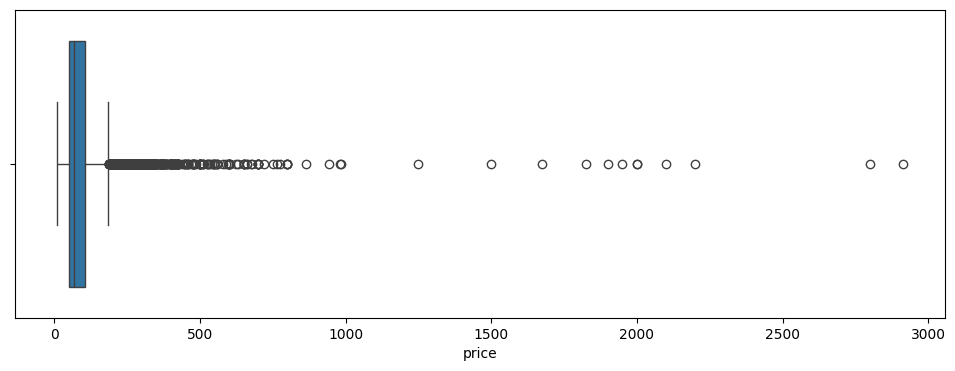

Q1: 49.230000000000004
Median:69.0
Q3: 104.0
Lower Whisker: 10.0
Upper Whisker: 185.0
Left Outliers Count: 0
Right Outliers Count: 607


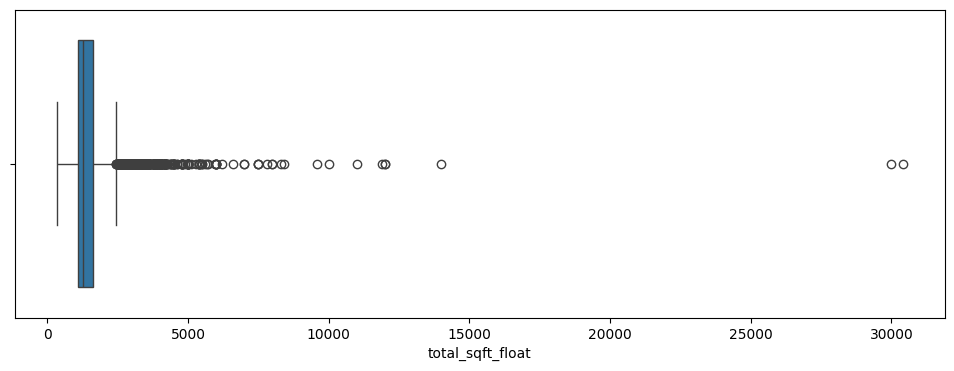

Q1: 1100.0
Median:1255.0
Q3: 1640.25
Lower Whisker: 350.0
Upper Whisker: 2450.0
Left Outliers Count: 0
Right Outliers Count: 515


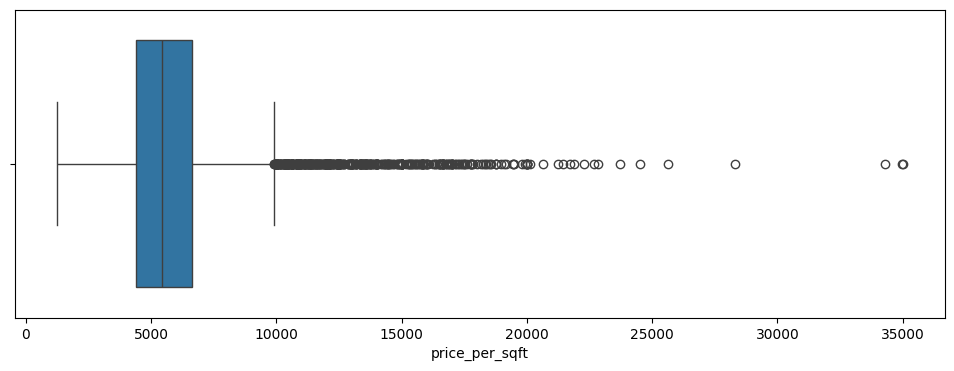

Q1: 4416.761041902605
Median:5417.855612768675
Q3: 6618.285650567095
Lower Whisker: 1250.0
Upper Whisker: 9904.371584699453
Left Outliers Count: 0
Right Outliers Count: 447


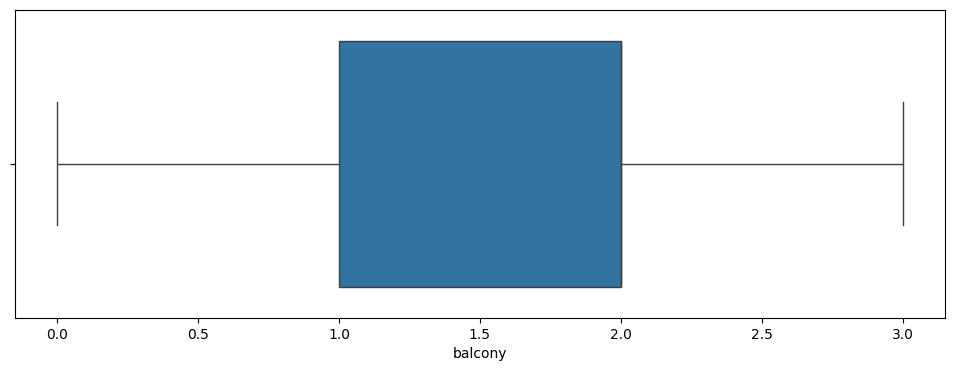

Q1: 1.0
Median:2.0
Q3: 2.0
Lower Whisker: 0.0
Upper Whisker: 3.0
Left Outliers Count: 0
Right Outliers Count: 0


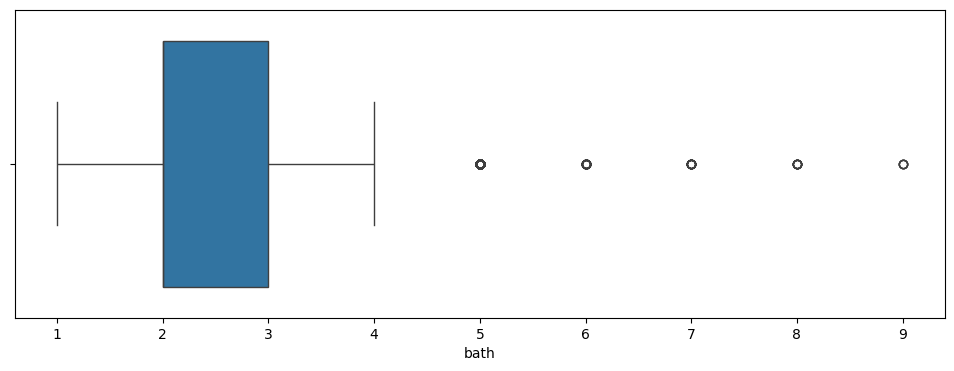

Q1: 2.0
Median:2.0
Q3: 3.0
Lower Whisker: 1.0
Upper Whisker: 4.0
Left Outliers Count: 0
Right Outliers Count: 204


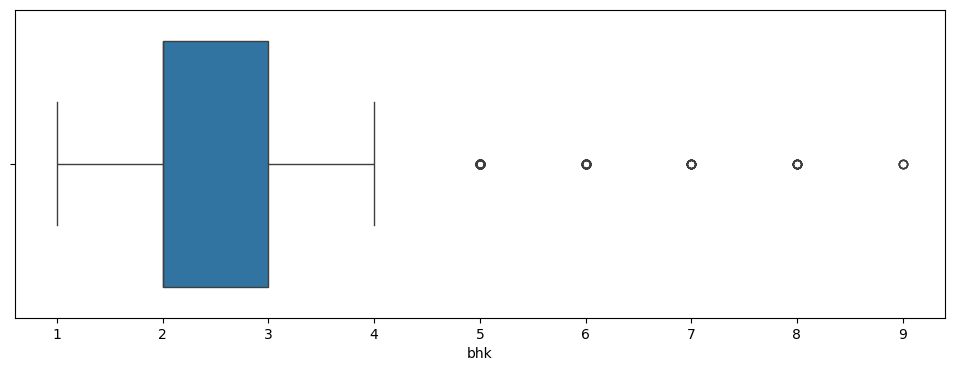

Q1: 2.0
Median:2.0
Q3: 3.0
Lower Whisker: 1
Upper Whisker: 4
Left Outliers Count: 0
Right Outliers Count: 129


In [110]:
# dung lai cai ben tren
for var in vars:
  q1 = df11[var].quantile(0.25)
  median = df11[var].median()
  q3 = df11[var].quantile(0.75)

  # theo tinh toan
  iqr = q3 - q1
  lower_fence = q1 - 1.5*iqr
  upper_fence = q3 + 1.5*iqr

  # tim thuc te
  lower_whisker = df11[df11[var] >= lower_fence][var].min()
  upper_whisker = df11[df11[var] <= upper_fence][var].max()

  left_outliers = df11[df11[var] < lower_fence].shape[0]
  right_outliers = df11[df11[var] > upper_fence].shape[0]

  plt.figure(figsize=(12, 4))
  sns.boxplot(x=df11[var])
  plt.show()

  print(f"Q1: {q1}")
  print(f"Median:{median}")
  print(f"Q3: {q3}")
  print(f"Lower Whisker: {lower_whisker}")
  print(f"Upper Whisker: {upper_whisker}")
  print(f"Left Outliers Count: {left_outliers}")
  print(f"Right Outliers Count: {right_outliers}")

Bài tập 4

In [111]:
# luu tam thoi
df12 = df11.drop(['area_type', 'availability', 'location', 'size', 'total_sqft'], axis='columns')

df12.to_csv("clean_data.csv", index=False)
df12.head()

,bath,balcony,price,total_sqft_float,bhk,price_per_sqft
0,3.0,2.0,150.0,1672.0,3,8971.291866
1,3.0,3.0,149.0,1750.0,3,8514.285714
2,3.0,2.0,150.0,1750.0,3,8571.428571
4,2.0,2.0,40.0,1250.0,2,3200.000000
5,2.0,2.0,83.0,1200.0,2,6916.666667


In [112]:
# luu vinh vien
folder_path = "/content/drive/MyDrive/Data Machine Learning/Ex2/"
df12.to_csv(folder_path + "clean_data.csv", index=False)